In [68]:
!pip install mpltern

In [69]:
!pip install GPy

In [70]:
import numpy as np
import GPy

from matplotlib import pyplot as plt
import mpltern
from mpltern.datasets import get_triangular_grid

In [71]:
def compositions_3d(compositions_2d):
    """Converting the compostions from the 2D triangle to a 3D simplex"""
    # In 3D space
    A_3d = np.array([1, 0, 0])
    B_3d = np.array([0, 1, 0])
    C_3d = np.array([0, 0, 1])

    # In 2D space
    A_2d = np.array([0, 0])  # A at the origin
    B_2d = np.array([1, 0])  # B at the x-axis = 1 point
    C_2d = np.array(
        [0.5, 0.5 * np.sqrt(3)]
    )  # C at the top of an equilateral triangle with the base along x of length 1.

    points = compositions_2d  # Read in the 2D compostions

    labmda_1 = ((B_2d[1] - C_2d[1])*(points[:,0] - C_2d[0]) + (C_2d[0] - B_2d[0])*(points[:,1] - C_2d[1]))/((B_2d[1] - C_2d[1])*(A_2d[0]-C_2d[0]) + (C_2d[0]-B_2d[0])*(A_2d[1]-C_2d[1]))

    labmda_2 = ((C_2d[1] - A_2d[1])*(points[:,0] - C_2d[0]) + (A_2d[0] - C_2d[0])*(points[:,1] - C_2d[1]))/((B_2d[1] - C_2d[1])*(A_2d[0]-C_2d[0]) + (C_2d[0]-B_2d[0])*(A_2d[1]-C_2d[1]))

    labmda_3 = 1 - labmda_1 - labmda_2

    points_3d = np.vstack([labmda_1, labmda_2, labmda_3]).T
    points_3d = points_3d.reshape(-1,3)
    return points_3d

def compositions_2d(compositions_3d):
      """Converting the compostions from the 3D simplex to a 2D triangle
      NOTE: the triangle is smaller than the simplex by a factor of sqrt(2)."""
      # In 3D space
      A_3d = np.array([1, 0, 0])
      B_3d = np.array([0, 1, 0])
      C_3d = np.array([0, 0, 1])

      # In 2D space
      A_2d = np.array([0, 0])  # A at the origin
      B_2d = np.array([1, 0])  # B at the x-axis = 1 point
      C_2d = np.array(
          [0.5, 0.5 * np.sqrt(3)]
      )  # C at the top of an equilateral triangle with the base along x of length 1.

      points = compositions_3d  # Read in the 3D compostions
      # Multiply 2D coordinates with the compositions for each component
      points_A = points[:, 0].reshape(-1, 1) * A_2d.reshape(1, -1)
      points_B = points[:, 1].reshape(-1, 1) * B_2d.reshape(1, -1)
      points_C = points[:, 2].reshape(-1, 1) * C_2d.reshape(1, -1)
      # Sum the coordinates for each component
      points_2d = points_A + points_B + points_C

      return points_2d

In [72]:
def mix_and_measure(compositions_array, vial_index_array, total_volume = 10, simulate=False):
  """Function that mixes a ternary mixture and measures the color"""
  measured_RGB_array = np.empty((0, 3))

  for vial_index, compositions in zip(vial_index_array, compositions_array):

    component_mL = compositions * total_volume

    if simulate == False:

      fill_vial(vial_index, component_mL)

      measured_RGB = measure_color()
      measured_RGB_array = np.concatenate((measured_RGB_array, measured_RGB.reshape(-1,3)), axis = 0)


    if simulate == True:

      A_dye = np.array([243.0, 12.0, 50.0])
      B_dye = np.array([100.0, 240.0, 0.0])
      C_dye = np.array([50.0, 2.0, 250.0])

      a_RGB = A_dye * compositions[0]
      b_RGB = B_dye * compositions[1]
      c_RGB = C_dye * compositions[2]

      measured_RGB = a_RGB + b_RGB + c_RGB
      measured_RGB_array = np.concatenate((measured_RGB_array, measured_RGB.reshape(-1,3)), axis = 0)

  return measured_RGB_array

def mix_and_measure_withwrench(compositions_array, vial_index_array, total_volume = 10, simulate=False):
  """Function that mixes a ternary mixture and measures the color
  Thows a monkey wrench in the works by injecting a spurious measurement."""

  measured_RGB_array = np.empty((0, 3))

  for vial_index, compositions in zip(vial_index_array, compositions_array):

    component_mL = compositions * total_volume

    if simulate == False:

      fill_vial(vial_index, component_mL)

      measured_RGB = measure_color()
      measured_RGB_array = np.concatenate((measured_RGB_array, measured_RGB.reshape(-1,3)), axis = 0)


    if simulate == True:

      A_dye = np.array([243.0, 12.0, 50.0])
      B_dye = np.array([100.0, 240.0, 0.0])
      C_dye = np.array([50.0, 2.0, 250.0])

      a_RGB = A_dye * compositions[0]
      b_RGB = B_dye * compositions[1]
      c_RGB = C_dye * compositions[2]

      measured_RGB = a_RGB + b_RGB + c_RGB
      if vial_index == 7:
        measured_RGB = np.array([255, 255, 255])
        print("Monkey wrench in the works!")

      measured_RGB_array = np.concatenate((measured_RGB_array, measured_RGB.reshape(-1,3)), axis = 0)

  return measured_RGB_array






In [73]:
A_mesh, B_mesh, C_mesh = get_triangular_grid(101)

A_mesh = A_mesh.reshape(-1, 1)
B_mesh = B_mesh.reshape(-1, 1)
C_mesh = C_mesh.reshape(-1, 1)

compositions = np.hstack([A_mesh, B_mesh, C_mesh])
comp_2d = compositions_2d(compositions)

domain_index = np.arange(compositions.shape[0])

In [74]:
groundtruth_RGB = mix_and_measure(compositions, domain_index, 10.0, simulate=True)

In [75]:
groundtruth_RGB

array([[243.  ,  12.  ,  50.  ],
       [241.57,  14.28,  49.5 ],
       [241.07,  11.9 ,  52.  ],
       ...,
       [ 51.  ,   6.76, 245.  ],
       [ 50.5 ,   4.38, 247.5 ],
       [ 50.  ,   2.  , 250.  ]])

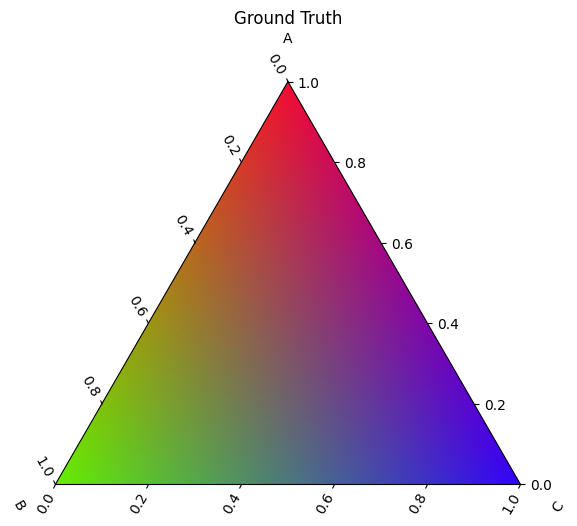

In [76]:
fig1 = plt.figure(figsize = (6,6))
ax1 = fig1.add_subplot(111, projection="ternary")
ax1.scatter(A_mesh, B_mesh, C_mesh,
            marker= "o",
            facecolors = groundtruth_RGB/256,
            s = 10,
            alpha=1,
            # edgecolors='r'
            )
ax1.set_tlabel('A')
ax1.set_llabel('B')
ax1.set_rlabel('C')
ax1.set_title('Ground Truth')
plt.show()

In [77]:
def transform(RGB):

  #Range must have a mean of 0. So for RGB values [0,255] we should subtract 127.5
  #Center the mean
  y = RGB - 127.5

  # #map range to -1,1
  y = y/127.5
  y = y*(1 - 1e-16) #Slightly scale to narrow the range for numerical stability at RGB = 0 or 255

  #Now to capture anything that falls outside that range
  #squash range with tanh
  y = np.arctanh(y)
  return y

def reverse_transform(y):
  #Reverse the squashing with arctanh
  y = np.tanh(y)

  #Mulitply by 127.5 to increase the range and add 127.5 to bring range to [0, 255]
  RGB = y*127.5 + 127.5

  return RGB

In [78]:
test = transform(np.array([0, 100, 255]))
test

array([-18.71497388,  -0.21912747,  18.71497388])

In [79]:
reverse_transform(np.array([-45, -0.222, 45]))

array([  0.       ,  99.6510071, 255.       ])

In [80]:
def train(training_x, training_y):
  """Function that builds a GP model and trains it
  expects training_x in 3D compositions
  and training y in 3D RGB values (i.e. [R, G, B])."""
  #Define the model
  kernel1 = GPy.kern.RBF(input_dim=3, variance=1., lengthscale=0.2)
  kernel2 = GPy.kern.Coregionalize(input_dim = 1, output_dim=3, rank=3 )

  kernel = kernel1 * kernel2

  #Range must have a mean of 0. So for RGB values [0,255] we should subtract 128
  # train_y = training_y - 128
  train_y = transform(training_y)

  m = GPy.models.GPRegression(training_x, train_y, kernel)

  #Optimize the model
  m.optimize()

  return m

def predict(m, test_x):

  mean, var = m.predict(test_x)

  #We subtracted 128 from the training points, so we should add those back.
  # mean = mean + 128
  mean = reverse_transform(mean)

  return mean, var

In [81]:
start_indexes = np.random.choice(domain_index, 5)

measured_compositions = compositions[start_indexes]
measured_RGB = groundtruth_RGB[start_indexes]

In [82]:
model = train(measured_compositions, measured_RGB)

In [83]:
model

GP_regression.,value,constraints,priors
mul.rbf.variance,0.03539773758486313,+ve,
mul.rbf.lengthscale,1.323591575377419,+ve,
mul.coregion.W,"(3, 3)",,
mul.coregion.kappa,"(3,)",+ve,
Gaussian_noise.variance,4.788124025246549e-10,+ve,


In [84]:
test_indexes = np.random.choice(domain_index, 11)

test_compositions = compositions[test_indexes]
test_RGB = groundtruth_RGB[test_indexes]

In [85]:
mean, var = predict(model, compositions)

In [86]:
mean

array([[129.32046266, 125.84805747, 126.30075877],
       [233.67320994,  26.29112691,  43.11004808],
       [233.35720213,  25.57695393,  44.48355365],
       ...,
       [107.12252738,  17.33124543, 195.0282752 ],
       [107.77651948,  16.77631099, 196.12994727],
       [108.43882297,  16.24793248, 197.18497489]])

In [87]:
test_compositions

array([[0.64, 0.04, 0.32],
       [0.25, 0.49, 0.26],
       [0.33, 0.37, 0.3 ],
       [0.49, 0.5 , 0.01],
       [0.39, 0.42, 0.19],
       [0.61, 0.28, 0.11],
       [0.35, 0.57, 0.08],
       [0.13, 0.44, 0.43],
       [0.59, 0.06, 0.35],
       [0.37, 0.23, 0.4 ],
       [0.58, 0.39, 0.03]])

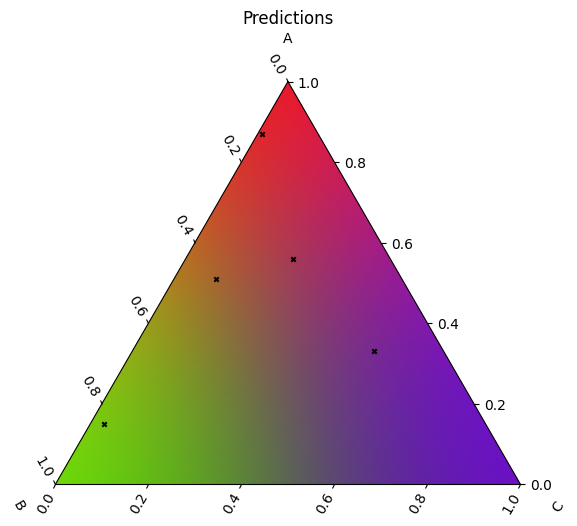

In [88]:
fig1 = plt.figure(figsize = (6,6))
ax1 = fig1.add_subplot(111, projection="ternary")
ax1.scatter(compositions[:,0], compositions[:,1], compositions[:,2],
            marker= "o",
            facecolors = mean/256,
            s = 10,
            alpha=1,
            # edgecolors='r'
            )

ax1.scatter(measured_compositions[:,0], measured_compositions[:,1], measured_compositions[:,2],
            marker= "x",
            facecolors = "k",
            s = 10,
            alpha=1,
            # edgecolors='r'
            )
ax1.set_tlabel('A')
ax1.set_llabel('B')
ax1.set_rlabel('C')
ax1.set_title('Predictions')
plt.show()

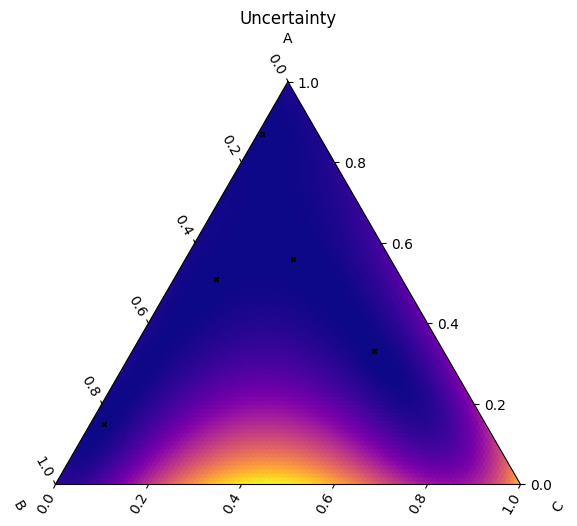

In [89]:
fig1 = plt.figure(figsize = (6,6))
ax1 = fig1.add_subplot(111, projection="ternary")
ax1.scatter(compositions[:,0], compositions[:,1], compositions[:,2],
            marker= "o",
            c = var.reshape(-1),
            cmap = "plasma",
            s = 10,
            alpha=1,
            # edgecolors='r'
            )

ax1.scatter(measured_compositions[:,0], measured_compositions[:,1], measured_compositions[:,2],
            marker= "x",
            facecolors = "k",
            s = 10,
            alpha=1,
            # edgecolors='r'
            )
ax1.set_tlabel('A')
ax1.set_llabel('B')
ax1.set_rlabel('C')
ax1.set_title('Uncertainty')
plt.show()

# Defining Acquisition Functions

In [90]:
def pure_explore(mean, var):
  next = np.argmax(var)
  return next

def min_confidence_to_target(mean, var, targetRGB):
  #Calculate the distance to the target
  diff = np.abs(mean - targetRGB)
  diff = np.sum(diff, axis=1).reshape(-1,1)

  #Calculate the confidence uncertainty in the diff
  sigma_diff = np.sqrt(var)

  #Find the index of the minimum of the lower confidence bound on the diff.
  acq_funct = diff - 2*sigma_diff
  next = np.argmin(acq_funct)

  return next, acq_funct

In [91]:
def discover_color_AL_campaign(starting_measurements, max_loops, simulate, show_fig ):
    #Number of random data points to start with
    # starting_measurements = 2

    #Number of active learning loops
    # max_loops = 20

    #Set-up the domain of mixtures
    A_mesh, B_mesh, C_mesh = get_triangular_grid(101)

    A_mesh = A_mesh.reshape(-1, 1)
    B_mesh = B_mesh.reshape(-1, 1)
    C_mesh = C_mesh.reshape(-1, 1)

    compositions = np.hstack([A_mesh, B_mesh, C_mesh])
    comp_2d = compositions_2d(compositions)

    domain_index = np.arange(compositions.shape[0])

    groundtruth_RGB = mix_and_measure(compositions, domain_index, 5, simulate=True)

    #Choose the first random points
    next_indexes = np.random.choice(domain_index, starting_measurements).reshape(-1,1)

    #Set up vial index container
    vial_index_array = np.arange(starting_measurements)

    #Set up containers for the measured compositions and RGB
    measured_indexes = np.empty((0, 1))
    measured_compositions = np.empty((0, 3))
    measured_RGB = np.empty((0, 3))

    #Set up containers for ploting
    variance_tracker = np.empty((0, 1))
    predicted_RGB = np.empty((compositions.shape[0], 3, 0))
    RMSE_tracker = np.empty((0, 1))

    for i in range(max_loops):
        #Find the compositions to be measured
        next_compositions = compositions[next_indexes].reshape(-1,3)

        #Find the next vials to be used
        ###count how many measurements have been done, and slice those off the vial index array
        next_vials = vial_index_array[measured_indexes.shape[0]:]

        #Mix those compositions and measure the RGB of them
        next_RGB = mix_and_measure(next_compositions,
                                    next_vials,
                                    5, simulate=simulate)
        print("Next vials \n")
        print(next_vials)
        print("Next RGB \n")
        print(next_RGB)

        #Add results to containers
        measured_indexes = np.concatenate((measured_indexes, next_indexes), axis=0)
        measured_compositions = np.concatenate((measured_compositions, next_compositions), axis=0)
        measured_RGB = np.concatenate((measured_RGB, next_RGB), axis=0)

        #Train the model
        model = train(measured_compositions, measured_RGB)

        #Predict over the whole domain
        mean, var = predict(model, compositions)
        #Add that to the trackers
        variance_tracker = np.concatenate((variance_tracker, np.sum(var).reshape(-1,1)), axis=0)
        predicted_RGB = np.concatenate((predicted_RGB, mean.reshape(-1, 3, 1)), axis=2)

        #Predict over just the un-measured locations
        unmeasured_indexes = np.setdiff1d(domain_index, measured_indexes)
        mean_unmeasured, var_unmeasured = predict(model, compositions[unmeasured_indexes])

        #Acquire
        next_unmeasured_indexes = pure_explore(mean_unmeasured, var_unmeasured)
        next_indexes = unmeasured_indexes[next_unmeasured_indexes]
        next_indexes = next_indexes.reshape(-1,1)

        #Add the next vial to the array
        vial_index_array = np.concatenate((vial_index_array,
                                        vial_index_array[-1].reshape(-1) + 1),
                                        axis=0)

        #Plot
        fig1 = plt.figure(figsize = (13,4))
        ax1 = fig1.add_subplot(121, projection="ternary")
        ax1.scatter(compositions[:,0], compositions[:,1], compositions[:,2],
                    marker= "o",
                    facecolors = mean/256,
                    s = 10,
                    alpha=1,
                    # edgecolors='r'
                    )

        ax1.scatter(measured_compositions[:,0], measured_compositions[:,1], measured_compositions[:,2],
                    marker= "o",
                    facecolors = "none",
                    edgecolors = "k",
                    s = 100,
                    alpha=1,
                    # edgecolors='r'
                    )
        ax1.scatter(compositions[next_indexes,0],
                    compositions[next_indexes,1],
                    compositions[next_indexes,2],
                    marker= "x",
                    facecolors = 'k',
                    s = 100,
                    alpha=1,
                    )
        ax1.set_tlabel('A')
        ax1.set_llabel('B')
        ax1.set_rlabel('C')
        ax1.set_title('Predictions')

        ax2 = fig1.add_subplot(122, projection="ternary")
        im = ax2.scatter(compositions[:,0], compositions[:,1], compositions[:,2],
                    marker= "o",
                    c = var.reshape(-1),
                    cmap = "plasma",
                    s = 10,
                    alpha=1,
                    # edgecolors='r'
                    )

        ax2.scatter(measured_compositions[:,0], measured_compositions[:,1], measured_compositions[:,2],
                    marker= "o",
                    facecolors = "none",
                    edgecolors = "k",
                    s = 100,
                    alpha=1,
                    # edgecolors='r'
                    )
        ax2.scatter(compositions[next_indexes,0],
                    compositions[next_indexes,1],
                    compositions[next_indexes,2],
                    marker= "x",
                    facecolors = 'k',
                    s = 100,
                    alpha=1,
                    )
        ax2.set_tlabel('A')
        ax2.set_llabel('B')
        ax2.set_rlabel('C')
        ax2.set_title('Uncertainty')
        fig1.colorbar(im, ax=ax2, label = "Variance")
        # ax2.colorbar(label = "Uncertainty")

        if show_fig:
          plt.show()
        else:
          plt.savefig(f'colorfig_{i}')

        fig2 = plt.figure(figsize = (4,4))
        ax1 = fig2.add_subplot(111)
        ax1.plot(np.arange(i+1), variance_tracker, marker = "o")
        ax1.set_xlabel("Loop")
        ax1.set_ylabel("Total Variance")
        ax1.set_title("Variance Trend")
        if show_fig:
          plt.show()
        else:
          plt.savefig(f'variance_performance_fig_{i}')


        if i != 0:
            previous_prediction_map = predicted_RGB[:, :, i-1]

            previous_prediction = previous_prediction_map[measured_indexes.flatten().astype(int)][-1,:]

            measurement = measured_RGB[-1,:]
            print("Previous Prediction ", previous_prediction)
            print("Measurement ", measurement)

            RMSE = np.sqrt(np.sum((measurement - previous_prediction)**2))
            RMSE_tracker = np.concatenate((RMSE_tracker, RMSE.reshape(-1,1)), axis=0)

            fig3 = plt.figure(figsize = (4,4))
            ax1 = fig3.add_subplot(111)
            ax1.plot(np.arange(i), RMSE_tracker, marker = "o")
            ax1.set_xlabel("Loop")
            ax1.set_ylabel("RMSE")
            ax1.set_title("RMSE Trend")
            if show_fig:
              plt.show()
            else:
              plt.savefig(f'RMSE_performance_fig_{i}')





In [92]:
def target_color_AL_campaign(starting_measurements, max_loops, target_RGB, simulate, show_fig ):
    #Number of random data points to start with
    # starting_measurements = 2

    #Number of active learning loops
    # max_loops = 20

    #Set-up the domain of mixtures
    A_mesh, B_mesh, C_mesh = get_triangular_grid(101)

    A_mesh = A_mesh.reshape(-1, 1)
    B_mesh = B_mesh.reshape(-1, 1)
    C_mesh = C_mesh.reshape(-1, 1)

    compositions = np.hstack([A_mesh, B_mesh, C_mesh])
    comp_2d = compositions_2d(compositions)

    domain_index = np.arange(compositions.shape[0])

    groundtruth_RGB = mix_and_measure(compositions, domain_index, 5, simulate=True)

    #Choose the first random points
    next_indexes = np.random.choice(domain_index, starting_measurements).reshape(-1,1)

    #Set up vial index container
    vial_index_array = np.arange(starting_measurements)

    #Set up containers for the measured compositions and RGB
    measured_indexes = np.empty((0, 1))
    measured_compositions = np.empty((0, 3))
    measured_RGB = np.empty((0, 3))

    #Set up containers for ploting
    variance_tracker = np.empty((0, 1))
    predicted_RGB = np.empty((compositions.shape[0], 3, 0))
    RMSE_tracker = np.empty((0, 1))

    for i in range(max_loops):
        #Find the compositions to be measured
        next_compositions = compositions[next_indexes].reshape(-1,3)

        #Find the next vials to be used
        ###count how many measurements have been done, and slice those off the vial index array
        next_vials = vial_index_array[measured_indexes.shape[0]:]

        #Mix those compositions and measure the RGB of them
        next_RGB = mix_and_measure(next_compositions,
                                    next_vials,
                                    5, simulate=simulate)
        print("Next vials \n")
        print(next_vials)
        print("Next RGB \n")
        print(next_RGB)

        #Add results to containers
        measured_indexes = np.concatenate((measured_indexes, next_indexes), axis=0)
        measured_compositions = np.concatenate((measured_compositions, next_compositions), axis=0)
        measured_RGB = np.concatenate((measured_RGB, next_RGB), axis=0)

        #Train the model
        model = train(measured_compositions, measured_RGB)

        #Predict over the whole domain
        mean, var = predict(model, compositions)
        #Add that to the trackers
        variance_tracker = np.concatenate((variance_tracker, np.sum(var).reshape(-1,1)), axis=0)
        predicted_RGB = np.concatenate((predicted_RGB, mean.reshape(-1, 3, 1)), axis=2)

        #Predict over just the un-measured locations
        unmeasured_indexes = np.setdiff1d(domain_index, measured_indexes)
        mean_unmeasured, var_unmeasured = predict(model, compositions[unmeasured_indexes])

        #Acquire
        next_unmeasured_indexes, acq_func =  min_confidence_to_target(mean_unmeasured, var_unmeasured,  target_RGB)
        next_indexes = unmeasured_indexes[next_unmeasured_indexes]
        next_indexes = next_indexes.reshape(-1,1)

        #Add the next vial to the array
        vial_index_array = np.concatenate((vial_index_array,
                                        vial_index_array[-1].reshape(-1) + 1),
                                        axis=0)

        #Plot
        fig1 = plt.figure(figsize = (13,4))
        ax1 = fig1.add_subplot(121, projection="ternary")
        ax1.scatter(compositions[:,0], compositions[:,1], compositions[:,2],
                    marker= "o",
                    facecolors = mean/256,
                    s = 10,
                    alpha=1,
                    # edgecolors='r'
                    )

        ax1.scatter(measured_compositions[:,0], measured_compositions[:,1], measured_compositions[:,2],
                    marker= "o",
                    facecolors = "none",
                    edgecolors = "k",
                    s = 100,
                    alpha=1,
                    # edgecolors='r'
                    )
        ax1.scatter(compositions[next_indexes,0],
                    compositions[next_indexes,1],
                    compositions[next_indexes,2],
                    marker= "x",
                    facecolors = 'k',
                    s = 100,
                    alpha=1,
                    )
        ax1.set_tlabel('A')
        ax1.set_llabel('B')
        ax1.set_rlabel('C')
        ax1.set_title('Predictions')

        ax2 = fig1.add_subplot(122, projection="ternary")
        im = ax2.scatter(compositions[:,0], compositions[:,1], compositions[:,2],
                    marker= "o",
                    c = var.reshape(-1),
                    cmap = "plasma",
                    s = 10,
                    alpha=1,
                    # edgecolors='r'
                    )

        ax2.scatter(measured_compositions[:,0], measured_compositions[:,1], measured_compositions[:,2],
                    marker= "o",
                    facecolors = "none",
                    edgecolors = "k",
                    s = 100,
                    alpha=1,
                    # edgecolors='r'
                    )
        ax2.scatter(compositions[next_indexes,0],
                    compositions[next_indexes,1],
                    compositions[next_indexes,2],
                    marker= "x",
                    facecolors = 'k',
                    s = 100,
                    alpha=1,
                    )
        ax2.set_tlabel('A')
        ax2.set_llabel('B')
        ax2.set_rlabel('C')
        ax2.set_title('Uncertainty')
        fig1.colorbar(im, ax=ax2, label = "Variance")
        # ax2.colorbar(label = "Uncertainty")

        if show_fig:
          plt.show()
        else:
          plt.savefig(f'colorfig_{i}')

        fig2 = plt.figure(figsize = (4,4))
        ax1 = fig2.add_subplot(111)
        ax1.plot(np.arange(i+1), variance_tracker, marker = "o")
        ax1.set_xlabel("Loop")
        ax1.set_ylabel("Total Variance")
        ax1.set_title("Variance Trend")
        if show_fig:
          plt.show()
        else:
          plt.savefig(f'variance_performance_fig_{i}')


        if i != 0:
            previous_prediction_map = predicted_RGB[:, :, i-1]

            previous_prediction = previous_prediction_map[measured_indexes.flatten().astype(int)][-1,:]

            measurement = measured_RGB[-1,:]
            print("Previous Prediction ", previous_prediction)
            print("Measurement ", measurement)

            RMSE = np.sqrt(np.sum((measurement - previous_prediction)**2))
            RMSE_tracker = np.concatenate((RMSE_tracker, RMSE.reshape(-1,1)), axis=0)

            fig3 = plt.figure(figsize = (4,4))
            ax1 = fig3.add_subplot(111)
            ax1.plot(np.arange(i), RMSE_tracker, marker = "o")
            ax1.set_xlabel("Loop")
            ax1.set_ylabel("RMSE")
            ax1.set_title("RMSE Trend")
            if show_fig:
              plt.show()
            else:
              plt.savefig(f'RMSE_performance_fig_{i}')





Next vials 

[0 1 2 3 4]
Next RGB 

[[131.97 128.66  62.  ]
 [104.88 117.84  98.  ]
 [128.4  102.58  87.5 ]
 [168.22  74.04  72.  ]
 [120.17 163.36  44.5 ]]


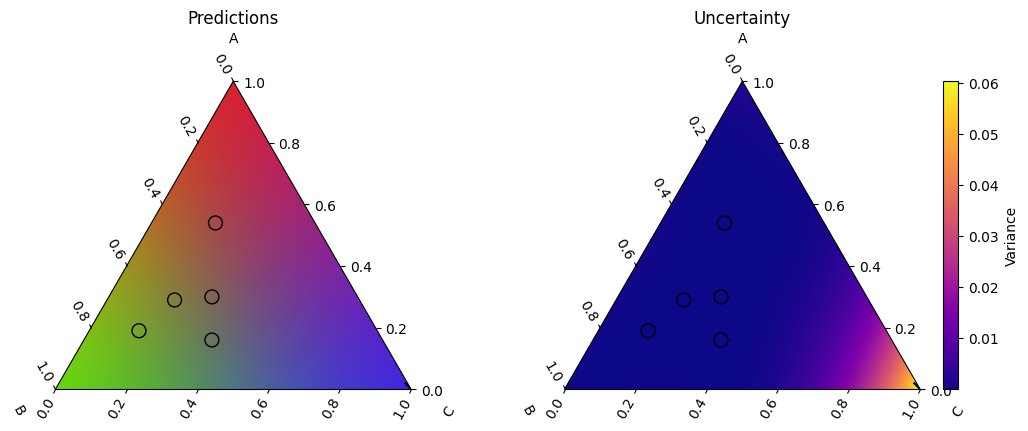

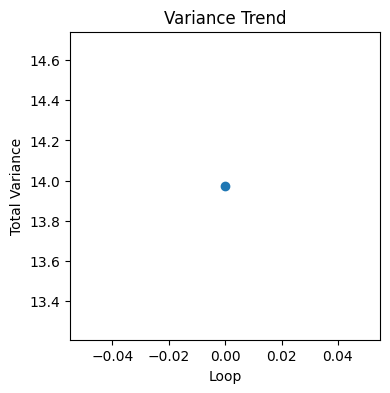

Next vials 

[5]
Next RGB 

[[ 50.   2. 250.]]


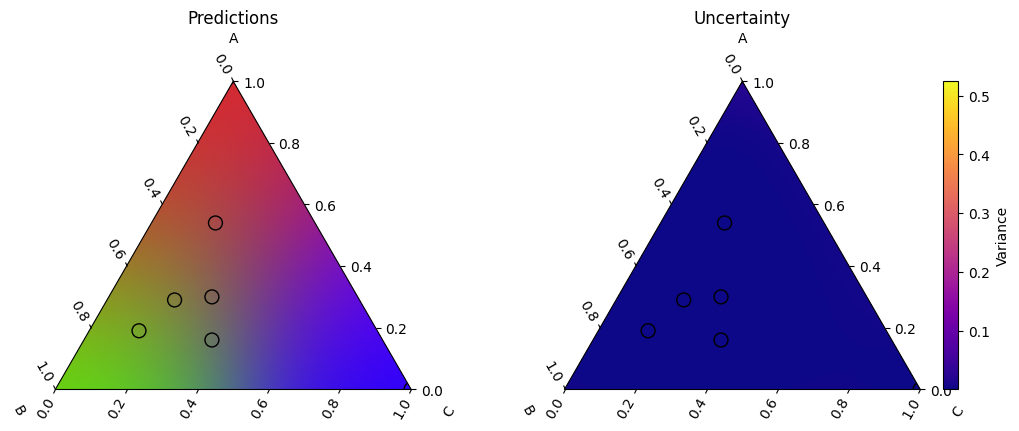

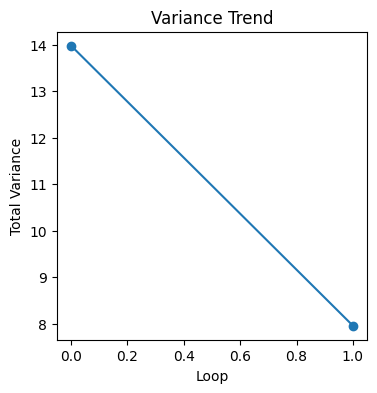

Previous Prediction  [ 64.89960213  38.94721157 221.81963204]
Measurement  [ 50.   2. 250.]


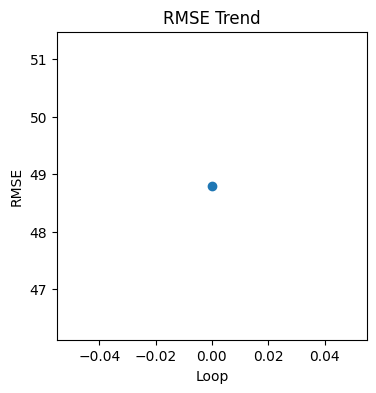

In [93]:
np.random.seed(2)
discover_color_AL_campaign(5, 2, True, True)

In [67]:
np.random.seed(2)
test_target = np.array([177, 13, 92])
target_color_AL_campaign(2, 15, test_target, True, True)

Output hidden; open in https://colab.research.google.com to view.

In [53]:
test_p = np.array([110.14535527, 143.94359569, 110.59822282 ])
test_m = np.array([100, 240, 0])

print((test_p - test_m))
print((test_p - test_m)**2)
print(np.sum((test_p - test_m)**2))
print(np.sqrt(np.sum((test_p - test_m)**2)))

[ 10.14535527 -96.05640431 110.59822282]
[  102.92823355  9226.83280897 12231.96689094]
21561.727933463073
146.8391226256241


In [30]:
test_y[1]

array([0.26159867, 0.78850875, 0.88044523])

In [ ]:
example_target = np.array([100, 100, 100])
diff = np.abs(mean - example_target)

In [ ]:
diff = np.sum(diff, axis=1).reshape(-1,1)

In [ ]:
np.min(diff)

16.46232142654941

In [ ]:
sigma_mean = np.sqrt(var)
sigma_diff = sigma_mean


In [ ]:
np.argmin(diff - 2*sigma_diff)

3531

In [ ]:
np.argmin(diff)

3531

# Active Learning Loops

Next vials 

[0 1]
Next RGB 

[[108.46  80.36 126.  ]
 [166.86  85.74  63.5 ]]


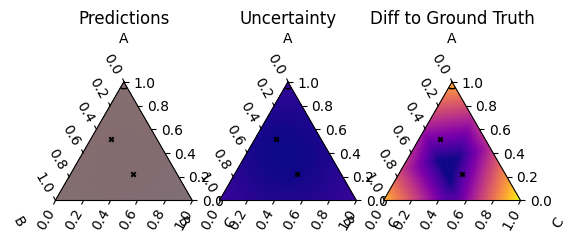

Next vials 

[2]
Next RGB 

[[243.  12.  50.]]


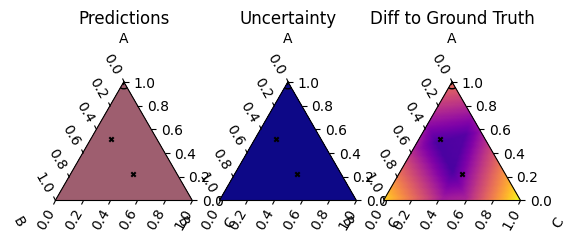

Next vials 

[3]
Next RGB 

[[243.  12.  50.]]


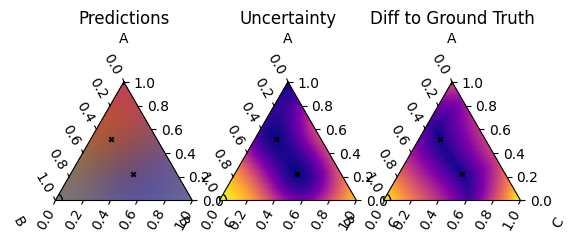

Next vials 

[4]
Next RGB 

[[100. 240.   0.]]


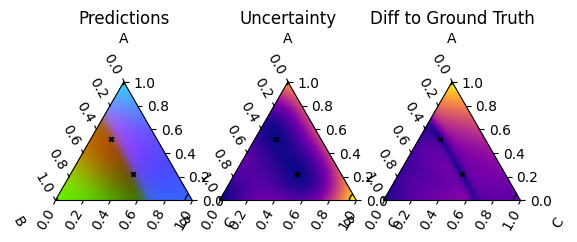

Next vials 

[5]
Next RGB 

[[ 50.   2. 250.]]


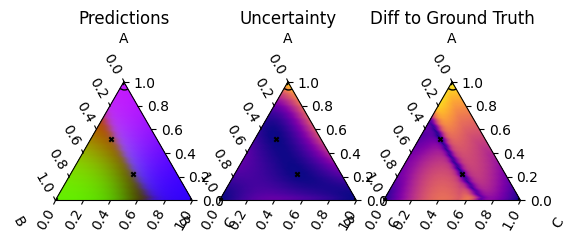

Next vials 

[6]
Next RGB 

[[241.07  11.9   52.  ]]


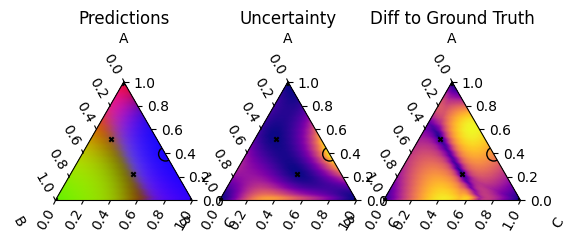

Next vials 

[7]
Next RGB 

[[125.27   5.9  172.  ]]


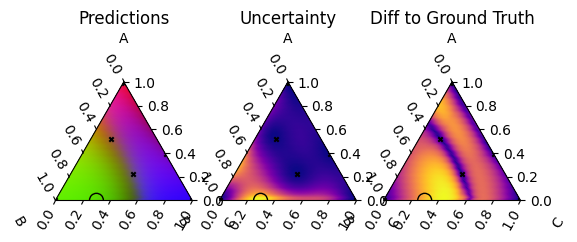

Next vials 

[8]
Next RGB 

[[ 85.  168.6  75. ]]


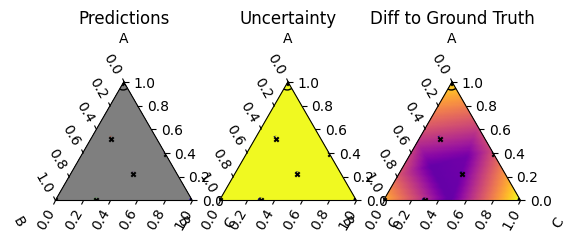

Next vials 

[9]
Next RGB 

[[241.57  14.28  49.5 ]]


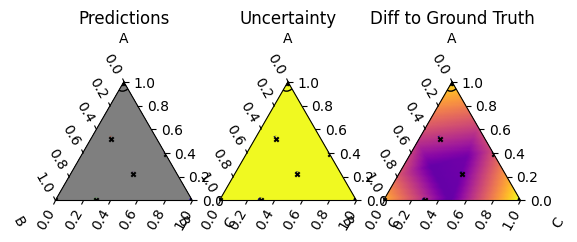

Next vials 

[10]
Next RGB 

[[240.14  16.56  49.  ]]


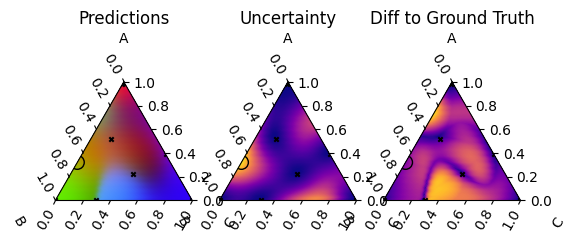

Next vials 

[11]
Next RGB 

[[145.76 167.04  16.  ]]


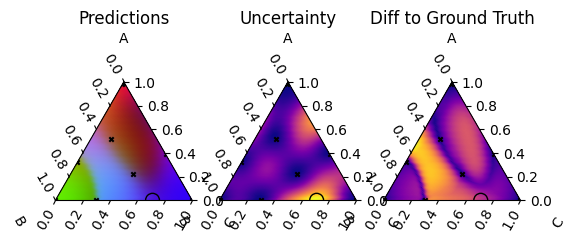

Next vials 

[12]
Next RGB 

[[ 64.5   71.02 177.5 ]]


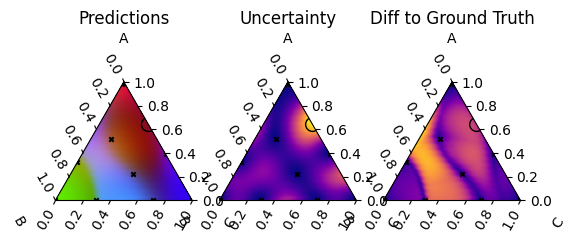

Next vials 

[13]
Next RGB 

[[173.52   8.4  122.  ]]


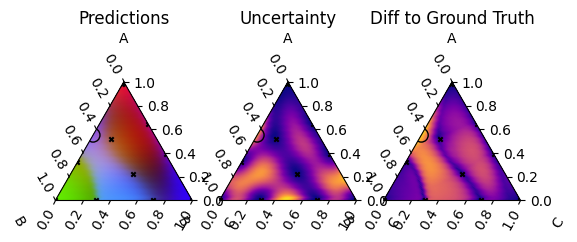

Next vials 

[14]
Next RGB 

[[178.65 114.6   27.5 ]]


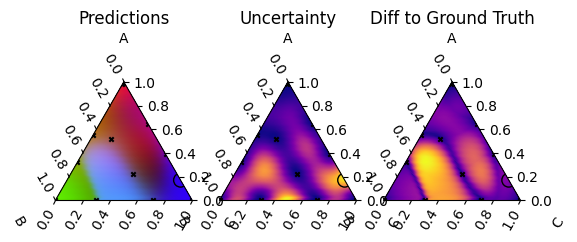

Next vials 

[15]
Next RGB 

[[ 82.81   3.7  216.  ]]


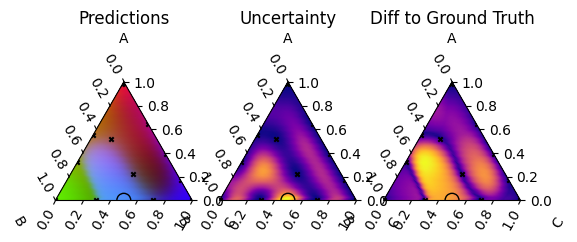

Next vials 

[16]
Next RGB 

[[ 75. 121. 125.]]


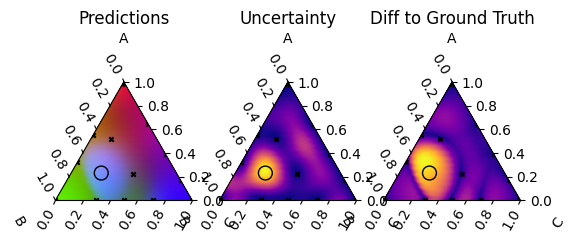

Next vials 

[17]
Next RGB 

[[121.89 135.2   66.5 ]]


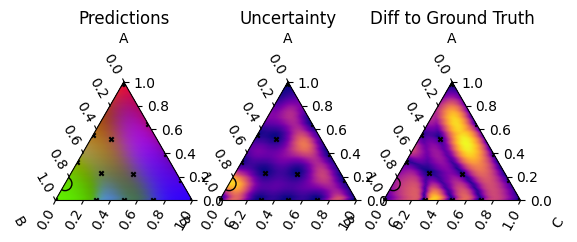

Next vials 

[18]
Next RGB 

[[120.02 208.08   7.  ]]


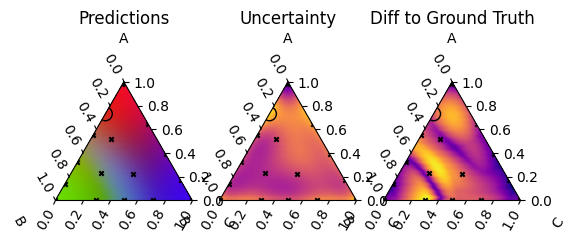

Next vials 

[19]
Next RGB 

[[204.39  73.56  36.5 ]]


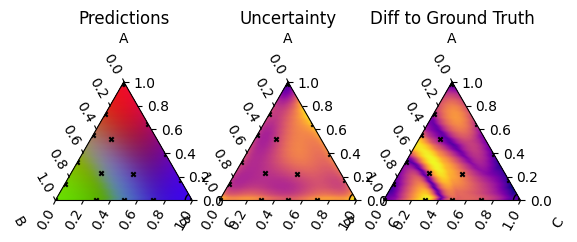

Next vials 

[20]
Next RGB 

[[ 50.   2. 250.]]


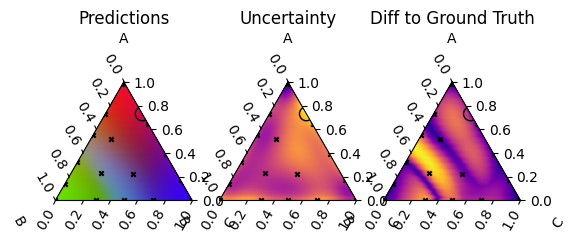

In [ ]:
#Number of random data points to start with
starting_measurements = 2

#Number of active learning loops
max_loops = 20

#Choose the first random points
next_indexes = np.random.choice(domain_index, starting_measurements).reshape(-1,1)

#Set up vial index container
vial_index_array = np.arange(starting_measurements)

#Set up containers for the measured compositions and RGB
measured_indexes = np.empty((0, 1))
measured_compositions = np.empty((0, 3))
measured_RGB = np.empty((0, 3))

for i in range(max_loops):
  #Find the compositions to be measured
  next_compositions = compositions[next_indexes].reshape(-1,3)

  #Find the next vials to be used
  ###count how many measurements have been done, and slice those off the vial index array
  next_vials = vial_index_array[measured_indexes.shape[0]:]

  #Mix those compositions and measure the RGB of them
  next_RGB = mix_and_measure(next_compositions,
                             next_vials,
                             10.0, simulate=True)
  print("Next vials \n")
  print(next_vials)
  print("Next RGB \n")
  print(next_RGB)

  #Add results to containers
  measured_indexes = np.concatenate((measured_indexes, next_indexes), axis=0)
  measured_compositions = np.concatenate((measured_compositions, next_compositions), axis=0)
  measured_RGB = np.concatenate((measured_RGB, next_RGB), axis=0)

  #Train the model
  model = train(measured_compositions, measured_RGB)

  #Predict over the whole domain
  mean, var = predict(model, compositions)

  #Acquire
  next_indexes = pure_explore(mean, var)
  next_indexes = next_indexes.reshape(-1,1)

  #Add the next vial to the array
  vial_index_array = np.concatenate((vial_index_array,
                                   vial_index_array[-1].reshape(-1) + 1),
                                   axis=0)

  #Plot
  fig1 = plt.figure(figsize = (6,24))
  ax1 = fig1.add_subplot(131, projection="ternary")
  ax1.scatter(compositions[:,0], compositions[:,1], compositions[:,2],
              marker= "o",
              facecolors = mean/256,
              s = 10,
              alpha=1,
              # edgecolors='r'
              )

  ax1.scatter(measured_compositions[:,0], measured_compositions[:,1], measured_compositions[:,2],
              marker= "x",
              facecolors = "k",
              s = 10,
              alpha=1,
              # edgecolors='r'
              )
  ax1.scatter(compositions[next_indexes,0],
              compositions[next_indexes,1],
              compositions[next_indexes,2],
              marker= "o",
              facecolors = 'none',
              s = 100,
              alpha=1,
              edgecolors='k'
              )
  ax1.set_tlabel('A')
  ax1.set_llabel('B')
  ax1.set_rlabel('C')
  ax1.set_title('Predictions')
  # plt.show()

  # fig1 = plt.figure(figsize = (6,6))
  ax2 = fig1.add_subplot(132, projection="ternary")
  ax2.scatter(compositions[:,0], compositions[:,1], compositions[:,2],
              marker= "o",
              c = var.reshape(-1),
              cmap = "plasma",
              s = 10,
              alpha=1,
              # edgecolors='r'
              )

  ax2.scatter(measured_compositions[:,0], measured_compositions[:,1], measured_compositions[:,2],
              marker= "x",
              facecolors = "k",
              s = 10,
              alpha=1,
              # edgecolors='r'
              )
  ax2.scatter(compositions[next_indexes,0],
              compositions[next_indexes,1],
              compositions[next_indexes,2],
              marker= "o",
              facecolors = 'none',
              s = 100,
              alpha=1,
              edgecolors='k'
              )
  ax2.set_tlabel('A')
  ax2.set_llabel('B')
  ax2.set_rlabel('C')
  ax2.set_title('Uncertainty')

  diff = np.abs(groundtruth_RGB - mean)
  diff = np.sum(diff, axis=1).reshape(-1)
  ax3 = fig1.add_subplot(133, projection="ternary")
  ax3.scatter(compositions[:,0], compositions[:,1], compositions[:,2],
              marker= "o",
              c = diff,
              cmap = "plasma",
              s = 10,
              alpha=1,
              # edgecolors='r'
              )

  ax3.scatter(measured_compositions[:,0], measured_compositions[:,1], measured_compositions[:,2],
              marker= "x",
              facecolors = "k",
              s = 10,
              alpha=1,
              # edgecolors='r'
              )
  ax3.scatter(compositions[next_indexes,0],
              compositions[next_indexes,1],
              compositions[next_indexes,2],
              marker= "o",
              facecolors = 'none',
              s = 100,
              alpha=1,
              edgecolors='k'
              )
  ax3.set_tlabel('A')
  ax3.set_llabel('B')
  ax3.set_rlabel('C')
  ax3.set_title('Diff to Ground Truth')
  plt.show()

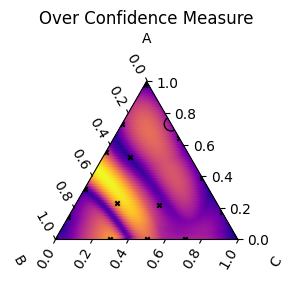

In [ ]:
fig1 = plt.figure(figsize = (8,10))
ax3 = fig1.add_subplot(133, projection="ternary")
ax3.scatter(compositions[:,0], compositions[:,1], compositions[:,2],
            marker= "o",
            c = diff/np.sqrt(var.reshape(-1)),
            cmap = "plasma",
            s = 10,
            alpha=1,
            # edgecolors='r'
            )

ax3.scatter(measured_compositions[:,0], measured_compositions[:,1], measured_compositions[:,2],
            marker= "x",
            facecolors = "k",
            s = 10,
            alpha=1,
            # edgecolors='r'
            )
ax3.scatter(compositions[next_indexes,0],
            compositions[next_indexes,1],
            compositions[next_indexes,2],
            marker= "o",
            facecolors = 'none',
            s = 100,
            alpha=1,
            edgecolors='k'
            )
ax3.set_tlabel('A')
ax3.set_llabel('B')
ax3.set_rlabel('C')
ax3.set_title('Over Confidence Measure')
plt.show()

## Now with the monkey wrench

In [ ]:
#Number of random data points to start with
starting_measurements = 2

#Number of active learning loops
max_loops = 20

#Choose the first random points
next_indexes = np.random.choice(domain_index, starting_measurements).reshape(-1,1)

#Set up vial index container
vial_index_array = np.arange(starting_measurements)

#Set up containers for the measured compositions and RGB
measured_indexes = np.empty((0, 1))
measured_compositions = np.empty((0, 3))
measured_RGB = np.empty((0, 3))

for i in range(max_loops):
  #Find the compositions to be measured
  next_compositions = compositions[next_indexes].reshape(-1,3)

  #Find the next vials to be used
  ###count how many measurements have been done, and slice those off the vial index array
  next_vials = vial_index_array[measured_indexes.shape[0]:]

  #Mix those compositions and measure the RGB of them
  next_RGB = mix_and_measure_withwrench(next_compositions,
                             next_vials,
                             10.0, simulate=True)
  print("Next vials \n")
  print(next_vials)
  print("Next RGB \n")
  print(next_RGB)

  #Add results to containers
  measured_indexes = np.concatenate((measured_indexes, next_indexes), axis=0)
  measured_compositions = np.concatenate((measured_compositions, next_compositions), axis=0)
  measured_RGB = np.concatenate((measured_RGB, next_RGB), axis=0)

  #Train the model
  model = train(measured_compositions, measured_RGB)

  #Predict over the whole domain
  mean, var = predict(model, compositions)

  #Acquire
  next_indexes = pure_explore(mean, var)
  next_indexes = next_indexes.reshape(-1,1)

  #Add the next vial to the array
  vial_index_array = np.concatenate((vial_index_array,
                                   vial_index_array[-1].reshape(-1) + 1),
                                   axis=0)

  #Plot
  fig1 = plt.figure(figsize = (6,12))
  ax1 = fig1.add_subplot(121, projection="ternary")
  ax1.scatter(compositions[:,0], compositions[:,1], compositions[:,2],
              marker= "o",
              facecolors = mean/256,
              s = 10,
              alpha=1,
              # edgecolors='r'
              )

  ax1.scatter(measured_compositions[:,0], measured_compositions[:,1], measured_compositions[:,2],
              marker= "x",
              facecolors = "k",
              s = 10,
              alpha=1,
              # edgecolors='r'
              )
  ax1.scatter(compositions[next_indexes,0],
              compositions[next_indexes,1],
              compositions[next_indexes,2],
              marker= "o",
              facecolors = 'none',
              s = 100,
              alpha=1,
              edgecolors='k'
              )
  ax1.set_tlabel('A')
  ax1.set_llabel('B')
  ax1.set_rlabel('C')
  ax1.set_title('Predictions')
  # plt.show()

  # fig1 = plt.figure(figsize = (6,6))
  ax2 = fig1.add_subplot(122, projection="ternary")
  ax2.scatter(compositions[:,0], compositions[:,1], compositions[:,2],
              marker= "o",
              c = var.reshape(-1),
              cmap = "plasma",
              s = 10,
              alpha=1,
              # edgecolors='r'
              )

  ax2.scatter(measured_compositions[:,0], measured_compositions[:,1], measured_compositions[:,2],
              marker= "x",
              facecolors = "k",
              s = 10,
              alpha=1,
              # edgecolors='r'
              )
  ax2.scatter(compositions[next_indexes,0],
              compositions[next_indexes,1],
              compositions[next_indexes,2],
              marker= "o",
              facecolors = 'none',
              s = 100,
              alpha=1,
              edgecolors='k'
              )
  ax2.set_tlabel('A')
  ax2.set_llabel('B')
  ax2.set_rlabel('C')
  ax2.set_title('Uncertainty')
  plt.show()

Output hidden; open in https://colab.research.google.com to view.

## Now trying to find a specific target

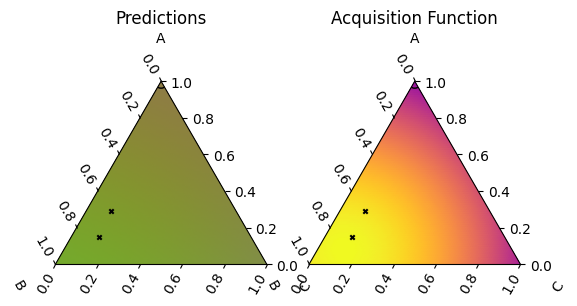

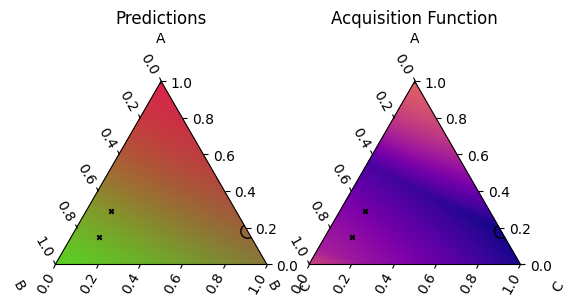

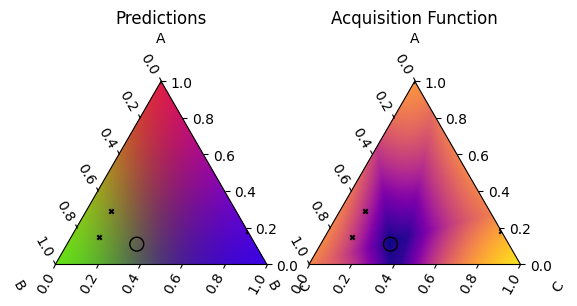

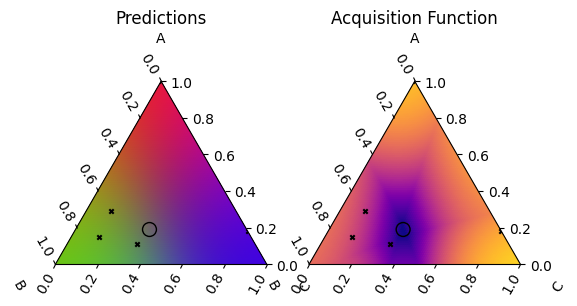

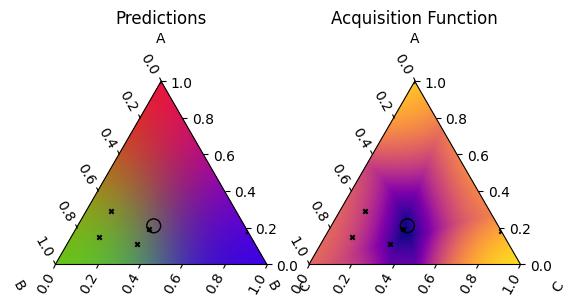

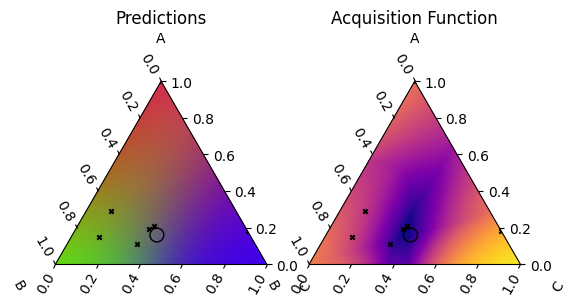

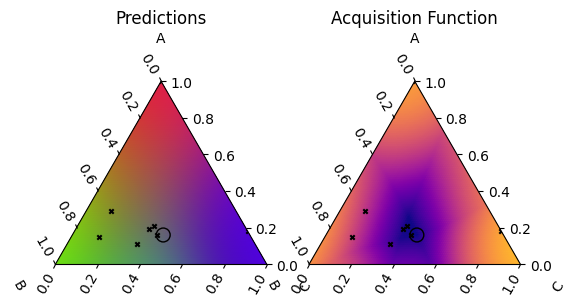

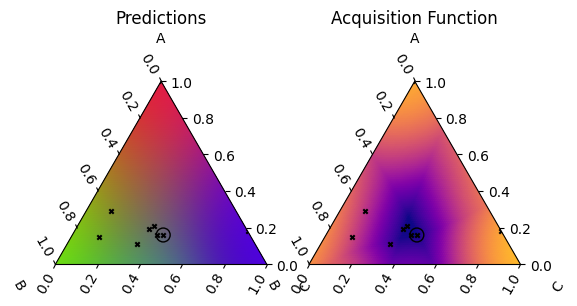

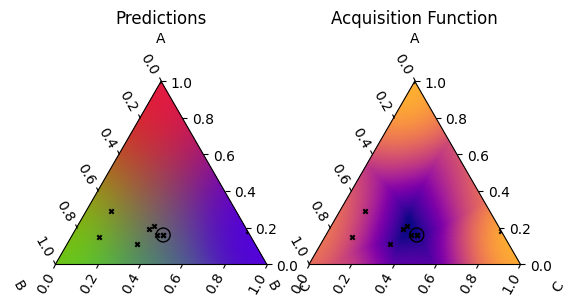

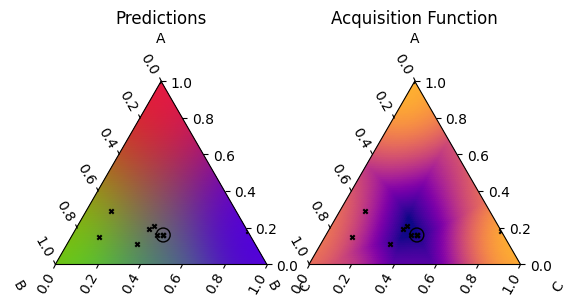

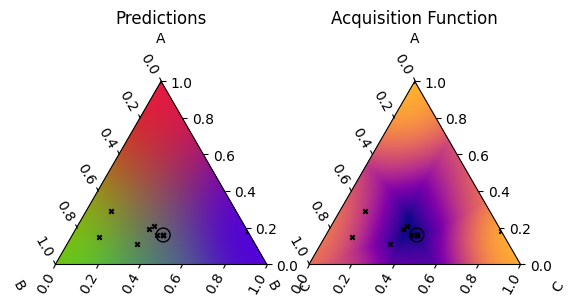

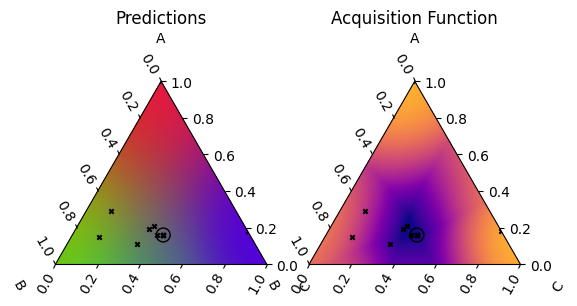

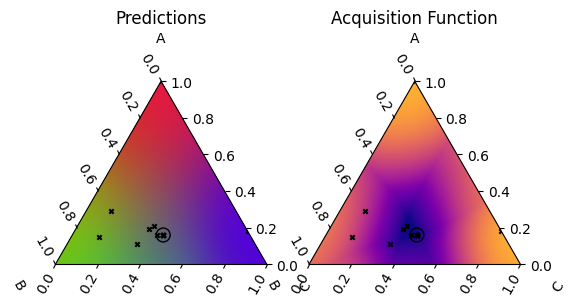

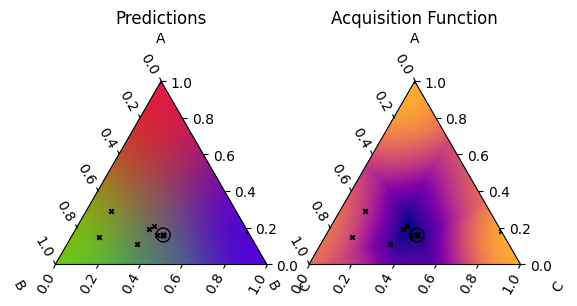

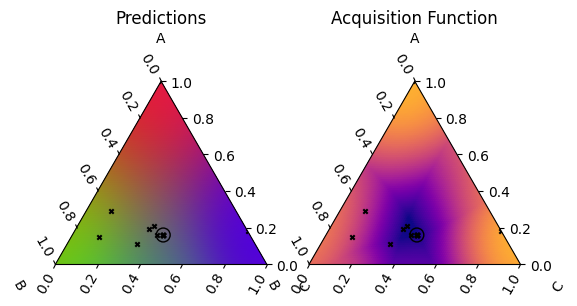

In [ ]:
#Target color
target_color = np.array([255, 0, 255])

#Number of random data points to start with
starting_measurements = 2

#Number of active learning loops
max_loops = 15

#Choose the first random points
next_indexes = np.random.choice(domain_index, starting_measurements).reshape(-1,1)

#Set up containers for the measured compositions and RGB
measured_indexes = np.empty((0, 1))
measured_compositions = np.empty((0, 3))
measured_RGB = np.empty((0, 3))

for i in range(max_loops):
  #Find the compositions to be measured
  next_compositions = compositions[next_indexes].reshape(-1,3)

  #Mix those compositions and measure the RGB of them
  next_RGB = mix_and_measure(next_compositions[:,0].reshape(-1,1),
                             next_compositions[:,1].reshape(-1,1),
                             next_compositions[:,2].reshape(-1,1),
                             10.0, simulate=True)

  #Add results to containers
  measured_indexes = np.concatenate((measured_indexes, next_indexes), axis=0)
  measured_compositions = np.concatenate((measured_compositions, next_compositions), axis=0)
  measured_RGB = np.concatenate((measured_RGB, next_RGB), axis=0)

  #Train the model
  model = train(measured_compositions, measured_RGB)

  #Predict over the whole domain
  mean, var = predict(model, compositions)

  #Acquire
  next_indexes, acq_func = min_confidence_to_target(mean, var, target_color)
  next_indexes = next_indexes.reshape(-1,1)



  #Plot
  fig1 = plt.figure(figsize = (6,12))
  ax1 = fig1.add_subplot(121, projection="ternary")
  ax1.scatter(compositions[:,0], compositions[:,1], compositions[:,2],
              marker= "o",
              facecolors = mean/256,
              s = 10,
              alpha=1,
              # edgecolors='r'
              )

  ax1.scatter(measured_compositions[:,0], measured_compositions[:,1], measured_compositions[:,2],
              marker= "x",
              facecolors = "k",
              s = 10,
              alpha=1,
              # edgecolors='r'
              )
  ax1.scatter(compositions[next_indexes,0],
              compositions[next_indexes,1],
              compositions[next_indexes,2],
              marker= "o",
              facecolors = 'none',
              s = 100,
              alpha=1,
              edgecolors='k'
              )
  ax1.set_tlabel('A')
  ax1.set_llabel('B')
  ax1.set_rlabel('C')
  ax1.set_title('Predictions')
  # plt.show()

  # fig1 = plt.figure(figsize = (6,6))
  ax2 = fig1.add_subplot(122, projection="ternary")
  ax2.scatter(compositions[:,0], compositions[:,1], compositions[:,2],
              marker= "o",
              c = acq_func.reshape(-1),
              cmap = "plasma",
              s = 10,
              alpha=1,
              # edgecolors='r'
              )

  ax2.scatter(measured_compositions[:,0], measured_compositions[:,1], measured_compositions[:,2],
              marker= "x",
              facecolors = "k",
              s = 10,
              alpha=1,
              # edgecolors='r'
              )
  ax2.scatter(compositions[next_indexes,0],
              compositions[next_indexes,1],
              compositions[next_indexes,2],
              marker= "o",
              facecolors = 'none',
              s = 100,
              alpha=1,
              edgecolors='k'
              )
  ax2.set_tlabel('A')
  ax2.set_llabel('B')
  ax2.set_rlabel('C')
  ax2.set_title('Acquisition Function')
  plt.show()

In [ ]:
measured_RGB

array([[135.47, 145.32,  44.5 ],
       [114.95, 174.86,  40.  ],
       [243.  ,  12.  ,  50.  ],
       [ 84.74,   3.8 , 214.  ],
       [ 99.23, 136.38,  88.  ],
       [109.67, 113.38,  97.  ],
       [112.03, 106.44, 100.5 ],
       [102.88, 108.32, 108.  ],
       [101.38, 101.18, 115.5 ],
       [101.38, 101.18, 115.5 ],
       [101.38, 101.18, 115.5 ],
       [101.38, 101.18, 115.5 ],
       [101.38, 101.18, 115.5 ],
       [101.38, 101.18, 115.5 ],
       [101.38, 101.18, 115.5 ],
       [101.38, 101.18, 115.5 ]])

In [ ]:

diff = np.abs(groundtruth_RGB - target_color)
diff = np.sum(diff, axis=1).reshape(-1,1)

index_1 = np.argmin(diff)
print(index_1)
groundtruth_RGB[index_1]

5150


array([ 50.,   2., 250.])

In [ ]:
diff[index_1]

array([212.])

In [ ]:
np.sum(np.abs(measured_RGB[-1,:] - target_color))

394.3

In [ ]:
import numpy as np

In [ ]:
def f(x):
  return (x-50)**2 - x

In [ ]:
all_indexes = np.arange(10)
measured_indexes = np.random.permutation(all_indexes)[:8]

unmeasured_indexes = np.setdiff1d(all_indexes, measured_indexes)
Y_unmeasured = f(unmeasured_indexes)
index_in_unmeasured = np.argmin(Y_unmeasured)

print(index_in_unmeasured)
print(unmeasured_indexes[index_in_unmeasured])
print(all_indexes[unmeasured_indexes[index_in_unmeasured]])

1
9
9


In [ ]:
print(np.sort(measured_indexes))

[0 1 2 3 5 6 7 8]


In [ ]:
Y_unmeasured = f(unmeasured_indexes)

In [ ]:
index_in_unmeasured = np.argmin(Y_unmeasured)

In [ ]:
index_in_unmeasured

5

In [ ]:
unmeasured_indexes[index_in_unmeasured]

5

In [ ]:
all_indexes[unmeasured_indexes[index_in_unmeasured]]

5